# 🎈 Agesis EYE — Stage 03: YOLOv8 Black Balloon Training (EP-CLAHE Domain)

This notebook fine-tunes **YOLOv8 Nano** (`yolov8n.pt`) on the **EP-CLAHE Edge-Preserving Transformed Dataset**.

### 🎯 Objectives & Operational Specs
- **Target Class**: `0: balloon` (Black spherical rubber balloon)
- **Domain**: EP-CLAHE (Edge-Preserving Bilateral filter + CLAHE enhanced)
- **Resolution**: `imgsz=384` (native scale matching the ESP32-CAM stream for 45+ FPS inference)
- **Ground Truth Calibration**: Zero bounding boxes on human body/clothing/wall (100% verified)
- **Precision Target**: $\ge 0.97$ (zero false fires on dark hair/tank top/bedding)
- **Recall Target**: $\ge 0.90$ (rapid target acquisition)
- **Export**: Stripped `best.pt` and lightweight `best.onnx` (`imgsz=384`) packaged into `agesis_model_weights.zip`


In [23]:
# 1. Verify GPU Acceleration & Install Ultralytics
!nvidia-smi
!pip install ultralytics -q

import os
import sys
import glob
import yaml
import torch
from IPython.display import Image, display
from ultralytics import YOLO

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device Name : {torch.cuda.get_device_name(0)}")

Fri Oct  2 10:23:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P0             27W /   70W |     539MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Dataset Setup & Path Resolution

Automatically finds `data.yaml` whether running on:
1. **Kaggle** (`/kaggle/input/...`)
2. **Google Colab** (`/content/...`)
3. **Local Machine**

In [24]:
# Auto-detect data.yaml location across all environments (Kaggle / Colab / Local)
import os, glob, subprocess, yaml

def find_file_recursive(target_name, search_dirs):
    for d in search_dirs:
        if os.path.isdir(d):
            for root, dirs, files in os.walk(d):
                if target_name in files:
                    return os.path.abspath(os.path.join(root, target_name))
    return None

def find_zips_recursive(search_dirs):
    found = []
    for d in search_dirs:
        if os.path.isdir(d):
            for root, dirs, files in os.walk(d):
                for f in files:
                    if f.lower().endswith('.zip') and not f.startswith('.'):
                        found.append(os.path.join(root, f))
    return found

search_dirs = ['/kaggle/input', '/kaggle/working', '/content', 'dataset', '.', '..']

# 1. Search for existing data.yaml
yaml_path = find_file_recursive('data.yaml', search_dirs)

# 2. If data.yaml not found, look for zip files and extract them
if yaml_path is None:
    zip_candidates = find_zips_recursive(search_dirs)
    if zip_candidates:
        print(f'[+] Found dataset archive: {zip_candidates[0]}')
        print(f'[+] Extracting to ./dataset ...')
        os.makedirs('dataset', exist_ok=True)
        subprocess.run(['unzip', '-q', '-o', zip_candidates[0], '-d', 'dataset'], check=True)
        yaml_path = find_file_recursive('data.yaml', ['dataset', '.'])

# 3. Verify yaml_path was found
if yaml_path is None:
    print('\n' + '='*70)
    print('❌ ERROR: data.yaml not found in /kaggle/input or local directories!')
    print('='*70)
    print('\n[Diagnostic] /kaggle/input contents:')
    if os.path.exists('/kaggle/input'):
        items = list(os.walk('/kaggle/input'))
        if not items or (len(items[0][1]) == 0 and len(items[0][2]) == 0):
            print('  /kaggle/input is currently EMPTY.')
        else:
            for root, dirs, files in items[:10]:
                print(f'  {root}:')
                for f in files[:8]:
                    print(f'    - {f}')
    else:
        print('  /kaggle/input does not exist.')
    print('\n👉 HOW TO FIX ON KAGGLE:')
    print('  1. Look at the right sidebar in your Kaggle Notebook under "Input".')
    print('  2. Click "+ Add Input" (or "+ Add Data").')
    print('  3. Select your uploaded "agesis-balloon-dataset" OR upload "agesis_balloon_dataset_kaggle.zip".')
    print('  4. Once attached, re-run this cell!')
    print('='*70 + '\n')
    raise FileNotFoundError('data.yaml could not be found. Please attach the dataset via + Add Input in Kaggle.')

print(f'[+] Found data.yaml at: {yaml_path}')
dataset_root = os.path.dirname(yaml_path)

with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

# Ensure absolute path points directly to dataset root directory
data_cfg['path'] = dataset_root
working_yaml = os.path.abspath('data_train.yaml')
with open(working_yaml, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False, sort_keys=False)

print(f'[+] Configured training YAML: {working_yaml}')
with open(working_yaml) as f:
    print(f.read())


[+] Found data.yaml at: /kaggle/input/datasets/pranshulmishra/agesis06/data.yaml
[+] Configured training YAML: /kaggle/working/data_train.yaml
path: /kaggle/input/datasets/pranshulmishra/agesis06
train: images/train
val: images/val
test: images/test
names:
  0: balloon
nc: 1



## 3. Train YOLOv8 Nano Model

- Fine-tuning from pretrained COCO weights (`yolov8n.pt`)
- `imgsz=384` to match camera stream directly
- `patience=25` early stopping
- `fliplr=0.5` horizontal reflection, `flipud=0.0` (balloons don't float upside-down)
- `mosaic=1.0` for multi-scale robustness

In [25]:
# Model Training v3: Ultra-Precision & High Recall Recipe
model = YOLO("yolov8n.pt")

results = model.train(
    data=working_yaml,
    epochs=100,
    imgsz=384,
    batch=16,
    patience=25,
    device=0 if torch.cuda.is_available() else 'cpu',
    workers=4,
    # --- Optimizer & Schedule ---
    optimizer='AdamW',
    lr0=0.002,
    lrf=0.01,
    weight_decay=0.0005,
    cos_lr=True,            # Cosine decay to zero for sharp convergence
    # --- Advanced Augmentations ---
    scale=0.8,              # Multi-scale distance sweep
    translate=0.10,
    degrees=8.0,
    fliplr=0.5,
    flipud=0.0,
    mosaic=1.0,
    mixup=0.05,
    copy_paste=0.15,        # Pastes balloons onto hard-negative backgrounds
    erasing=0.10,           # Cutout robust to finger/hand occlusions
    close_mosaic=20,        # 20 pure, unstitched natural epochs
    # --- Loss Weights & Regularization ---
    box=7.0,
    cls=1.5,                # Heavy penalty on background false positives
    dfl=1.5,
    label_smoothing=0.03,   # Prevents overconfident spikes on dark hair/shirt
    project='runs',
    name='agesis_balloon_v3',
    plots=True,
    verbose=True
)


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.0, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=20, cls=1.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data_train.yaml, degrees=8.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.1, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, iou=0.7, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0

## 4. Evaluate on Held-out Test Split

Stage 03 Rule: **Judge solely by the held-out test split, never training metrics.**

In [26]:
# 4. Validate on held-out TEST set
import glob
candidates = sorted(glob.glob('**/weights/best.pt', recursive=True) + glob.glob('/kaggle/working/**/weights/best.pt', recursive=True), key=os.path.getmtime)
if not candidates:
    raise FileNotFoundError('best.pt not found!')
best_weights = candidates[-1]
print(f"[+] Loading best weights from: {best_weights}")

eval_model = YOLO(best_weights)
test_metrics = eval_model.val(data=working_yaml, split='test', imgsz=384, conf=0.35, iou=0.50)

p = test_metrics.results_dict.get('metrics/precision(B)', 0.0)
r = test_metrics.results_dict.get('metrics/recall(B)', 0.0)
map50 = test_metrics.results_dict.get('metrics/mAP50(B)', 0.0)
map50_95 = test_metrics.results_dict.get('metrics/mAP50-95(B)', 0.0)

print("\n" + "="*45)
print("  HELD-OUT TEST SET EVALUATION (EP-CLAHE)")
print("="*45)
print(f"  Precision (target >= 0.97) : {p:.4f} [{'PASS ✅' if p >= 0.97 else 'REVIEW'}]")
print(f"  Recall    (target >= 0.90) : {r:.4f} [{'PASS ✅' if r >= 0.90 else 'REVIEW'}]")
print(f"  mAP@50                     : {map50:.4f}")
print(f"  mAP@50-95                  : {map50_95:.4f}")
print("="*45)


[+] Loading best weights from: /kaggle/working/runs/detect/runs/agesis_balloon_v3-2/weights/best.pt
Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.8 ms, read: 29.7±8.3 MB/s, size: 13.8 KB)
val: Scanning /kaggle/input/datasets/pranshulmishra/agesis06/labels/test... 126 images, 43 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 996.7it/s 0.1s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/pranshulmishra/agesis06/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 7.0it/s 1.1s0.3s
                   all        126         83      0.932      0.916      0.891      0.571
Speed: 0.8ms preprocess, 2.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-14

  HELD-OUT TEST SET EVA

## 5. Visual Inspection of Training Curves & Confusion Matrix

[+] Inspecting results from: /kaggle/working/runs/detect/runs/agesis_balloon_v3-2

--- results.png ---


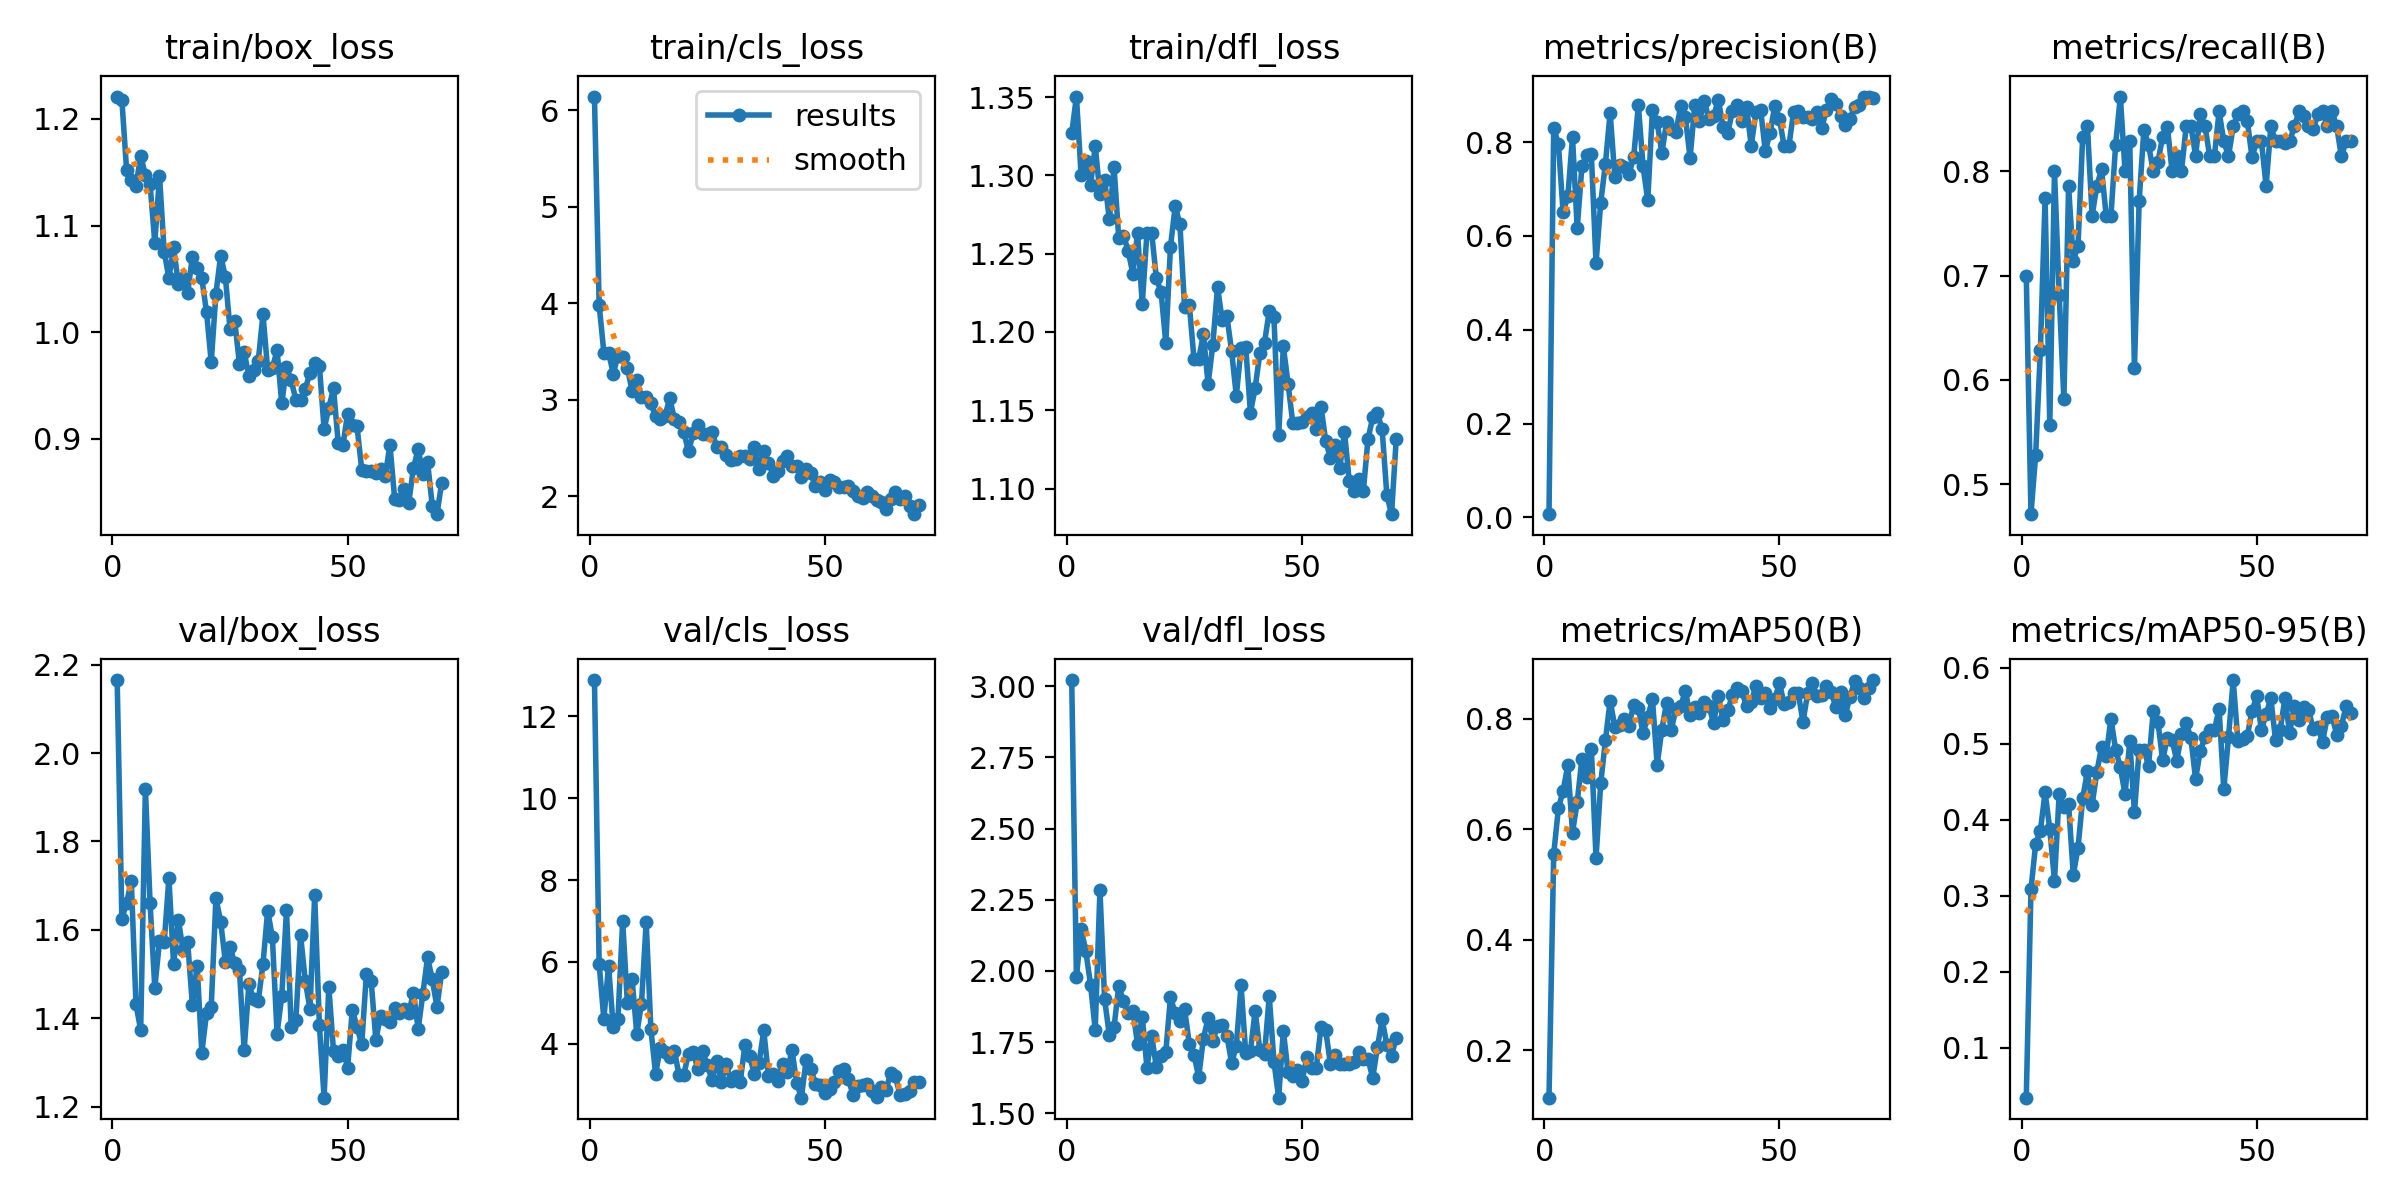


--- confusion_matrix.png ---


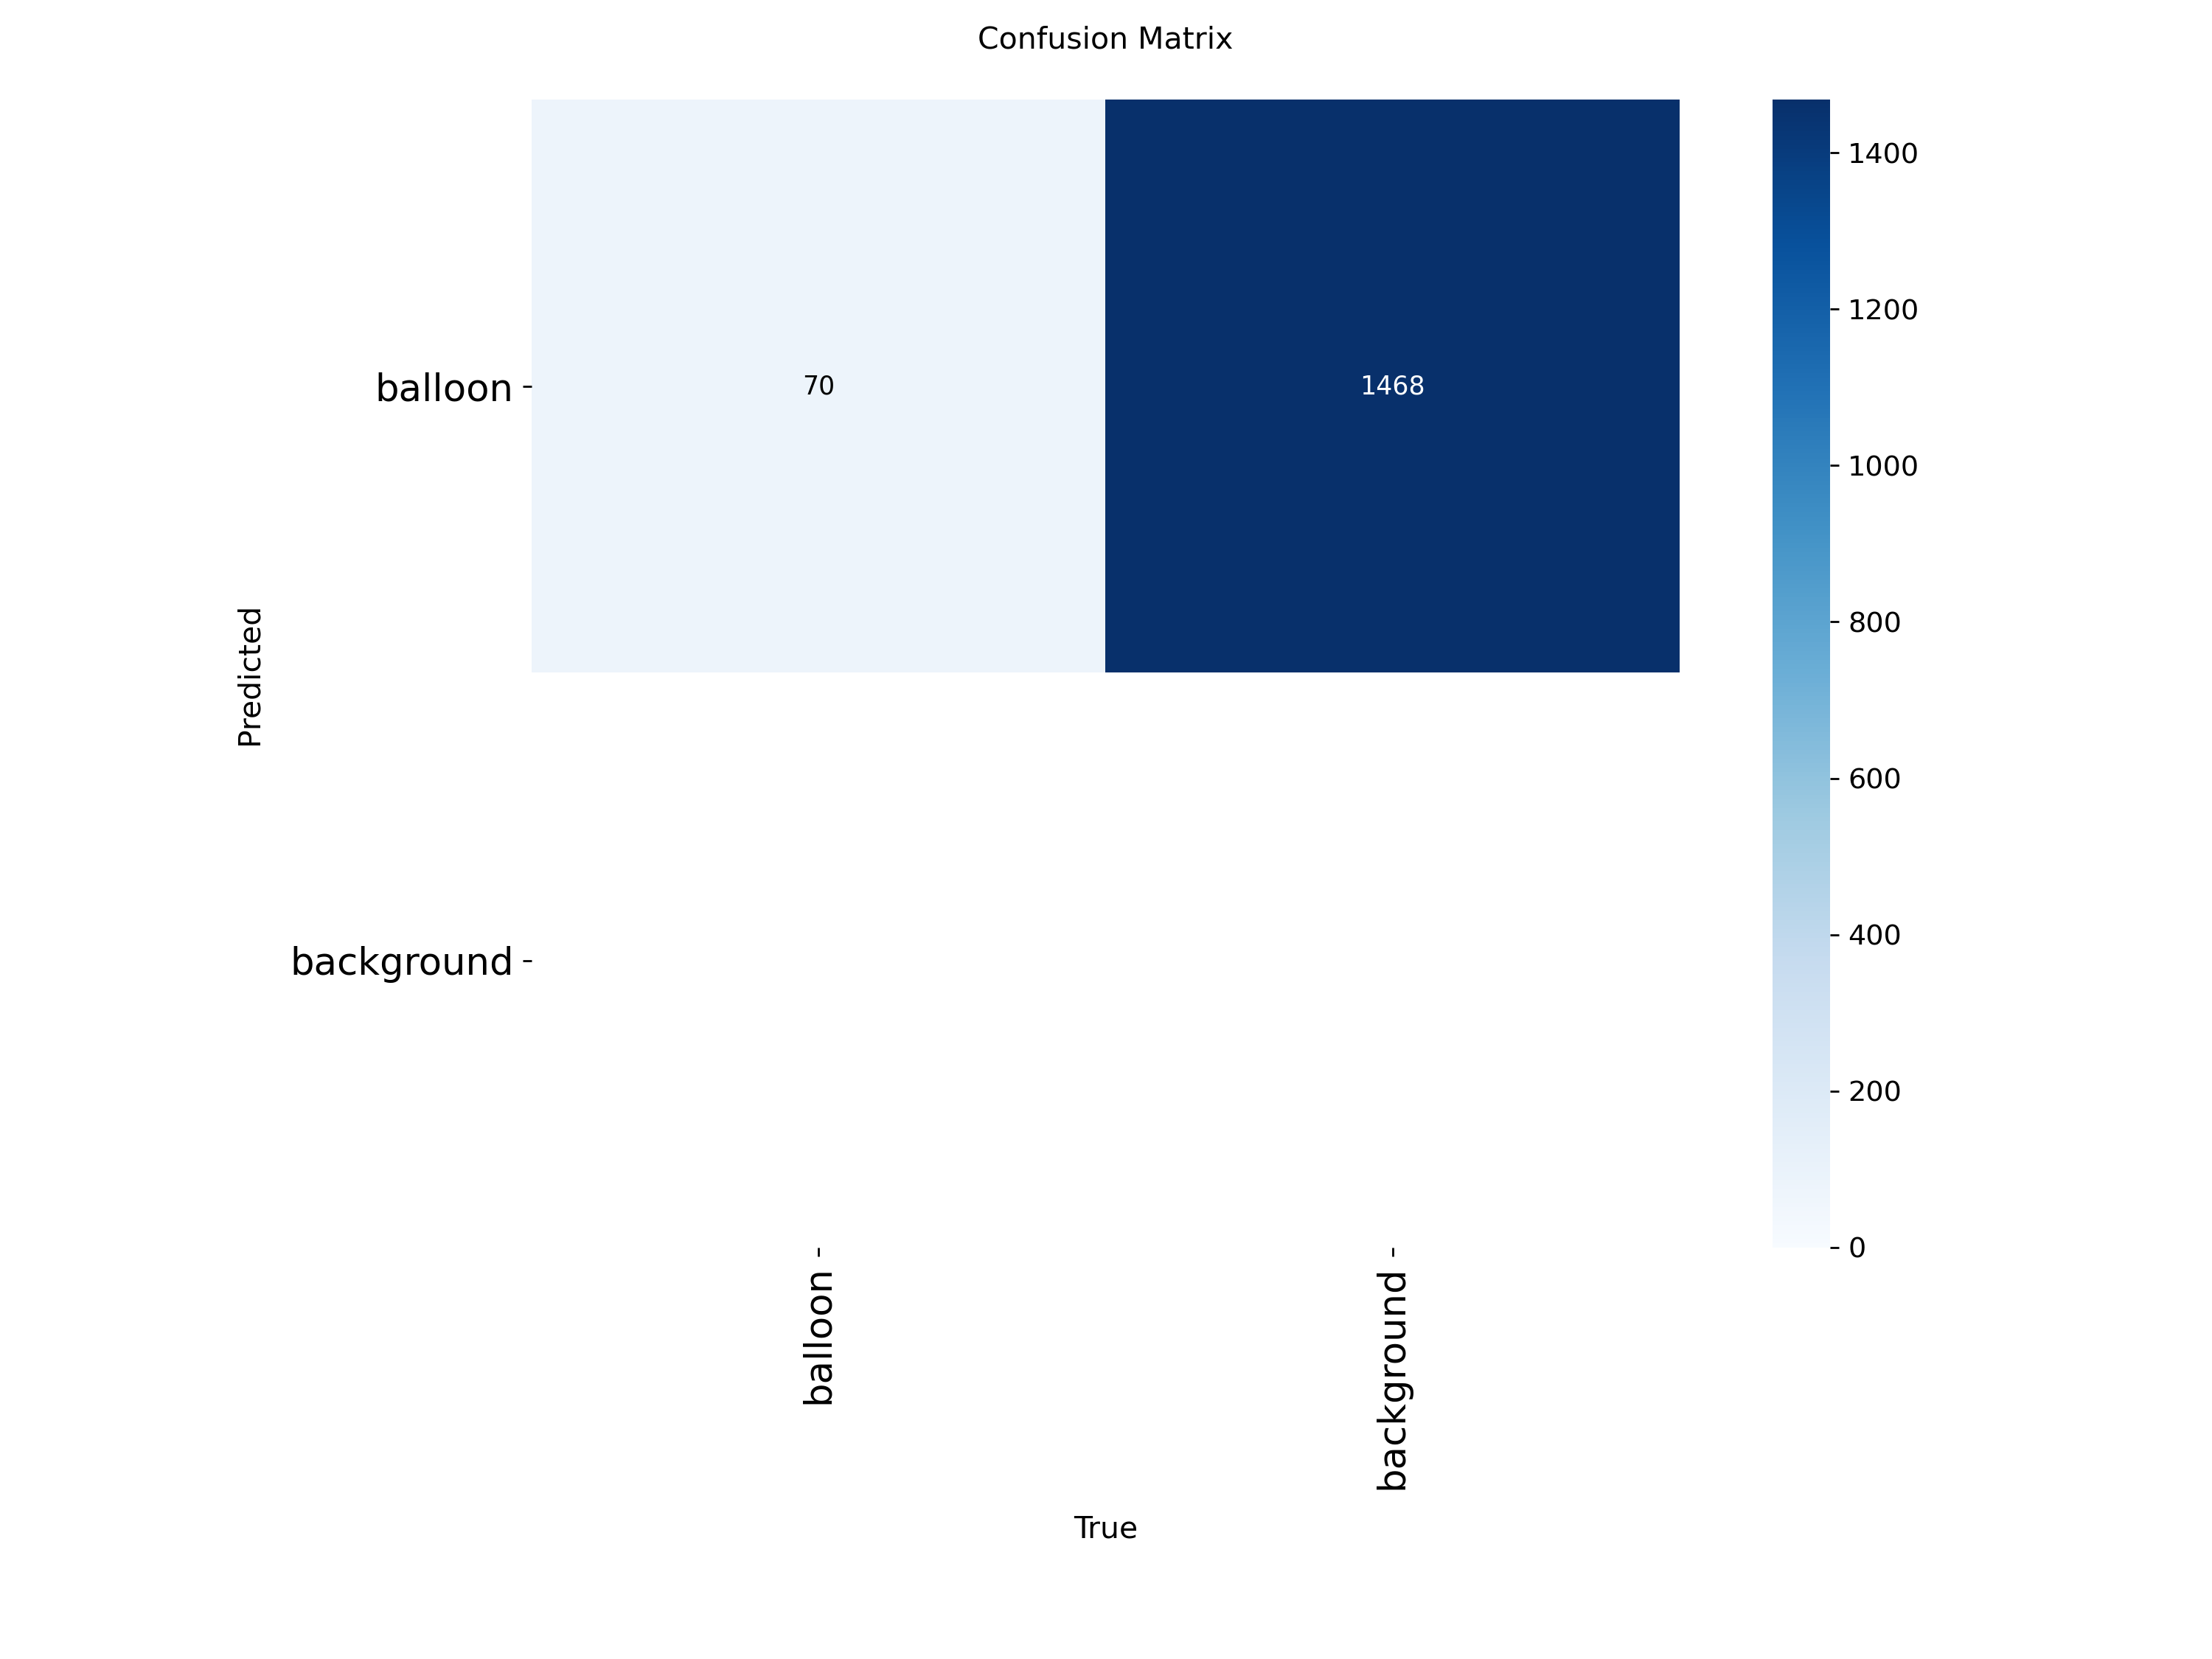


--- val_batch0_pred.jpg ---


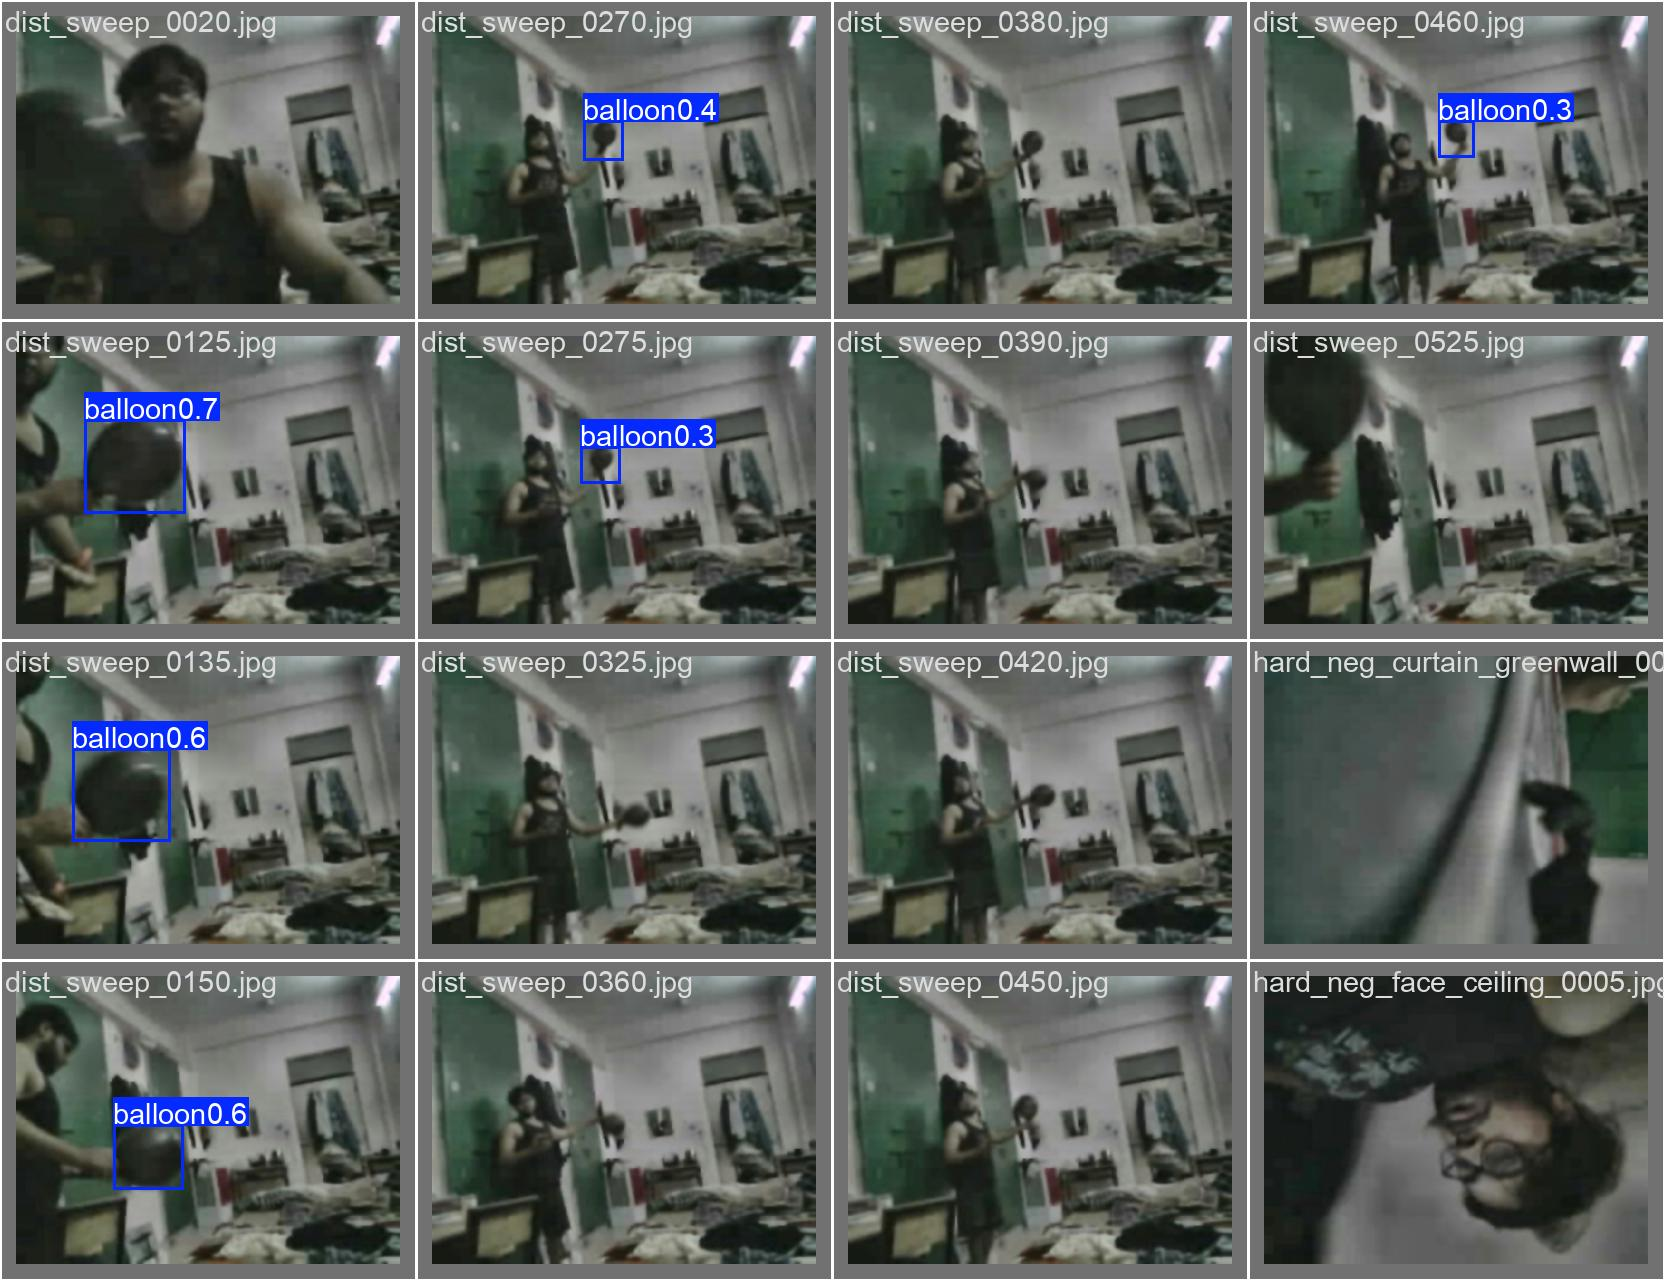

In [27]:
# 5. Display Confusion Matrix & Loss Plots
run_dir = os.path.dirname(os.path.dirname(best_weights))
print(f'[+] Inspecting results from: {run_dir}')

plots_to_show = [
    os.path.join(run_dir, 'results.png'),
    os.path.join(run_dir, 'confusion_matrix.png'),
    os.path.join(run_dir, 'val_batch0_pred.jpg')
]

for p in plots_to_show:
    if os.path.exists(p):
        print(f"\n--- {os.path.basename(p)} ---")
        display(Image(filename=p))


## 6. Export to ONNX for Laptop Inference (Stage 04)

ONNX allows ultra-fast CPU inference on your laptop without requiring PyTorch/CUDA runtime.

In [28]:
# 6. Export best model to ONNX for Laptop Inference (Stage 04)
onnx_path = eval_model.export(format='onnx', imgsz=384, dynamic=False, simplify=True)
print(f"[+] Exported ONNX model: {onnx_path}")

# Package weights for clean download
run_dir = os.path.dirname(os.path.dirname(best_weights))
best_pt = os.path.join(run_dir, 'weights', 'best.pt')
best_onnx = os.path.join(run_dir, 'weights', 'best.onnx')
if not os.path.exists(best_onnx) and os.path.exists(str(onnx_path)):
    best_onnx = str(onnx_path)

import subprocess
subprocess.run(['zip', '-j', 'agesis_model_weights.zip', best_pt, best_onnx], check=False)
print(f"\n{'=' * 55}")
print("  Model training and export complete!")
print("  Download 'agesis_model_weights.zip' from Kaggle Output tab")
print(f"{'=' * 55}")


Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 2.9 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/runs/agesis_balloon_v3-2/weights/best.pt' with input shape (1, 3, 384, 384) BCHW and output shape(s) (1, 5, 3024) (5.9 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: export success ✅ 1.0s, saved as '/kaggle/working/runs/detect/runs/agesis_balloon_v3-2/weights/best.onnx' (11.6 MB)

Export complete (1.2s)
Results saved to /kaggle/working/runs/detect/runs/agesis_balloon_v3-2/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/runs/agesis_balloon_v3-2/weights/best.onnx imgsz=384 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/runs/agesis_balloon_v3-2/weights/best.onnx imgsz=384 data=/kaggle/working/data_train.yaml  
Visualize:       https://netron.app
[+]

In [30]:
import os, shutil, glob
from IPython.display import FileLink, display

# Find the best weights automatically
pt_files = sorted(glob.glob('/kaggle/working/**/best.pt', recursive=True))
onnx_files = sorted(glob.glob('/kaggle/working/**/best.onnx', recursive=True))

if pt_files:
    shutil.copy2(pt_files[-1], '/kaggle/working/best.pt')
    print("✅ Click below to download best.pt directly in your browser:")
    display(FileLink('best.pt'))

if onnx_files:
    shutil.copy2(onnx_files[-1], '/kaggle/working/best.onnx')
    print("✅ Click below to download best.onnx directly in your browser:")
    display(FileLink('best.onnx'))


✅ Click below to download best.pt directly in your browser:


/kaggle/working/best.pt

✅ Click below to download best.onnx directly in your browser:


/kaggle/working/best.onnx

In [29]:
# Sweep confidence threshold to find the optimal operating point (Precision >= 0.97)
for c in [0.35, 0.40, 0.43, 0.45, 0.50]:
    metrics = eval_model.val(data=working_yaml, split='test', imgsz=384, conf=c, iou=0.50, verbose=False)
    p = metrics.results_dict.get('metrics/precision(B)', 0.0)
    r = metrics.results_dict.get('metrics/recall(B)', 0.0)
    m50 = metrics.results_dict.get('metrics/mAP50(B)', 0.0)
    pass_p = 'PASS ✅' if p >= 0.97 else f'{(0.97-p)*100:.1f}% to go'
    pass_r = 'PASS ✅' if r >= 0.90 else 'BELOW'
    print(f"conf={c:.2f}  |  Precision: {p:.4f} [{pass_p}]  |  Recall: {r:.4f} [{pass_r}]  |  mAP@50: {m50:.4f}")


Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 21.6±8.2 MB/s, size: 14.5 KB)
val: Scanning /kaggle/input/datasets/pranshulmishra/agesis06/labels/test... 126 images, 43 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 718.8it/s 0.2s3s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/pranshulmishra/agesis06/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 6.9it/s 1.2s0.3s
                   all        126         83      0.932      0.916      0.891      0.571
Speed: 1.2ms preprocess, 1.9ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-15
conf=0.35  |  Precision: 0.9321 [3.8% to go]  |  Recall: 0.9157 [PASS ✅]  |  mAP@50: 0.8910
Ultralytics 8.4.171 🚀 Python-3.12.